In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
df = pd.read_csv('drug200.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nTarget Distribution:\n", df['Drug'].value_counts())
print("\nMissing Values:\n", df.isnull().sum())

Shape: (200, 6)

First 5 rows:
    Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  DrugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  DrugY

Target Distribution:
 Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

Missing Values:
 Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64


In [ ]:
X = df.drop('Drug', axis=1)
y = df['Drug']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
categorical_cols = ['Sex', 'BP', 'Cholesterol']
numerical_cols   = ['Age', 'Na_to_K']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Train samples: 160
Test samples: 40


In [ ]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('dt', DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)
dt_pred = dt_pipeline.predict(X_test)

In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

In [ ]:
# Decision Tree Results
print("=== DECISION TREE ===")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred, target_names=le.classes_))

# Random Forest Results
print("\n=== RANDOM FOREST ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, target_names=le.classes_))

=== DECISION TREE ===
Accuracy: 0.975
              precision    recall  f1-score   support

       DrugY       0.95      1.00      0.97        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40


=== RANDOM FOREST ===
Accuracy: 0.975
              precision    recall  f1-score   support

       DrugY       0.95      1.00      0.97        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40


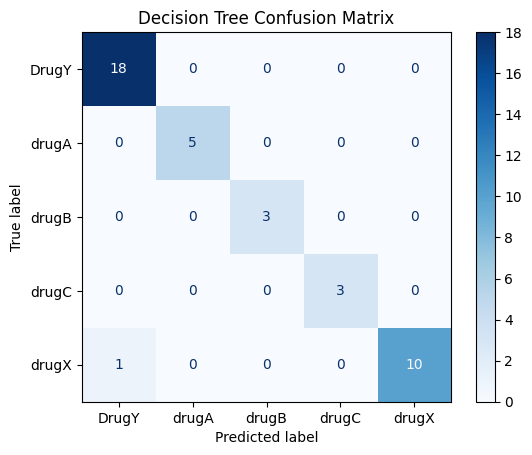

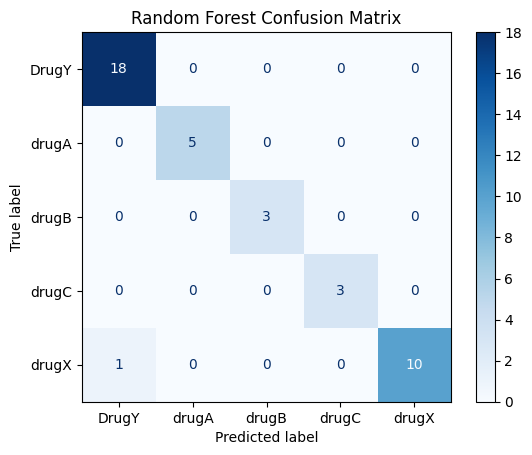

In [ ]:
# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.show()

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

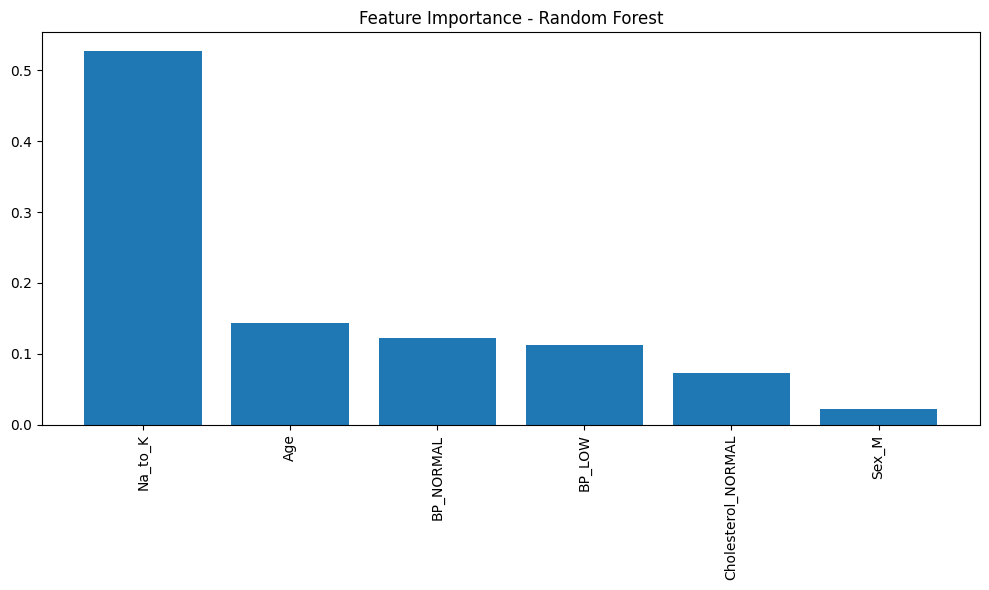

In [ ]:
rf_model = rf_pipeline.named_steps['rf']
feature_names = numerical_cols + list(
    rf_pipeline.named_steps['preprocessor']
    .named_transformers_['cat'].get_feature_names_out(categorical_cols)
)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance - Random Forest")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# For Decision Tree
param_grid_dt = {
    'dt__max_depth': [3, 5, 7, 10, None],
    'dt__min_samples_split': [2, 5, 10],
    'dt__criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(dt_pipeline, param_grid_dt, cv=5, n_jobs=-1)
grid_dt.fit(X_train, y_train)
print("Best DT Params:", grid_dt.best_params_)

# For Random Forest
param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [5, 10, None],
    'rf__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=5, n_jobs=-1)
grid_rf.fit(X_train, y_train)
print("Best RF Params:", grid_rf.best_params_)

Best DT Params: {'dt__criterion': 'gini', 'dt__max_depth': 5, 'dt__min_samples_split': 2}
Best RF Params: {'rf__max_depth': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}


In [ ]:
best_dt = grid_dt.best_estimator_
best_rf = grid_rf.best_estimator_

print("Final DT Test Accuracy:", accuracy_score(y_test, best_dt.predict(X_test)))
print("Final RF Test Accuracy:", accuracy_score(y_test, best_rf.predict(X_test)))

Final DT Test Accuracy: 0.975
Final RF Test Accuracy: 0.975


## Performance Analysis

Both the Decision Tree and Random Forest models achieved a high accuracy of **0.975 (97.5%)** on the test set. This indicates excellent performance in classifying the different drug types.

From the classification reports, we can observe that for both models, most drug classes (DrugY, drugA, drugB, drugC) show perfect precision, recall, and f1-scores of 1.00, meaning they were classified without any errors for these specific classes. The `drugX` class had slightly lower recall (0.91) and f1-score (0.95), suggesting a few instances of `drugX` might have been misclassified.

The confusion matrices visually confirm these findings, showing very few, if any, misclassifications, particularly for `drugX`.

Hyperparameter tuning using GridSearchCV helped optimize the models. The best parameters found were:
- **Decision Tree**: `dt__criterion='gini'`, `dt__max_depth=5`, `dt__min_samples_split=2`
- **Random Forest**: `rf__max_depth=5`, `rf__min_samples_split=2`, `rf__n_estimators=50`

After tuning, both models maintained their high accuracy, demonstrating robustness. Given the small dataset and high accuracy, these models appear very effective for this drug classification task.